In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error,r2_score,mean_absolute_error
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor,AdaBoostRegressor
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression,Lasso,Ridge  
from sklearn.model_selection import RandomizedSearchCV
from catboost import CatBoostRegressor
from xgboost import XGBRegressor
import warnings

In [33]:
df=pd.read_csv("data/stud.csv")

In [34]:
df

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75
...,...,...,...,...,...,...,...,...
995,female,group E,master's degree,standard,completed,88,99,95
996,male,group C,high school,free/reduced,none,62,55,55
997,female,group C,high school,free/reduced,completed,59,71,65
998,female,group D,some college,standard,completed,68,78,77


In [35]:
X = df.drop(columns=["math_score"])

In [36]:
y=df["math_score"]

In [37]:
y

0      72
1      69
2      90
3      47
4      76
       ..
995    88
996    62
997    59
998    68
999    77
Name: math_score, Length: 1000, dtype: int64

In [38]:
warnings.filterwarnings('ignore')

In [39]:
num_features=X.select_dtypes(exclude='object').columns
cat_features=X.select_dtypes(include='object').columns

from sklearn.preprocessing import OneHotEncoder,StandardScaler
from sklearn.compose import ColumnTransformer

num_transformer=StandardScaler()
cat_transformer=OneHotEncoder()

preprocessor= ColumnTransformer(
    [
        ("OneHotEncoder",cat_transformer,cat_features),
        ("StandardScaler",num_transformer,num_features),
    ]
)


In [40]:
X = preprocessor.fit_transform(X)

In [41]:
X

array([[ 1.        ,  0.        ,  0.        , ...,  1.        ,
         0.19399858,  0.39149181],
       [ 1.        ,  0.        ,  0.        , ...,  0.        ,
         1.42747598,  1.31326868],
       [ 1.        ,  0.        ,  0.        , ...,  1.        ,
         1.77010859,  1.64247471],
       ...,
       [ 1.        ,  0.        ,  0.        , ...,  0.        ,
         0.12547206, -0.20107904],
       [ 1.        ,  0.        ,  0.        , ...,  0.        ,
         0.60515772,  0.58901542],
       [ 1.        ,  0.        ,  0.        , ...,  1.        ,
         1.15336989,  1.18158627]], shape=(1000, 19))

In [43]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [ ]:
def model_eval(true,pred):
    mae=mean_absolute_error(true,pred)
    mse=mean_squared_error(true,pred)
    rmse=np.sqrt(mean_squared_error(true,pred))
    r2=r2_score(true,pred)

    return mae,mse,rmse,r2


In [61]:
models={
    "LinearRegression": LinearRegression(),
    "Lasso": Lasso(),
    "Ridge": Ridge(),
    "KNeighborsRegressor":KNeighborsRegressor(),
    "DecisionTreeRegressor":DecisionTreeRegressor(),
    "RandomForestRegressor":RandomForestRegressor(),
    "XGBRegressor":XGBRegressor(),
    "CatBoostRegressor":CatBoostRegressor(),
    "AdaBoostRegressor":AdaBoostRegressor()
}
model_list=[]
r2_list=[]

for i in range(len(list(models))):
    model=list(models.values())[i]
    model_list.append(list(models.keys())[i])

    model.fit(X_train,y_train)

    y_train_pred=model.predict(X_train)
    y_test_pred=model.predict(X_test)

    trainmae, trainmse , trainrse, trainr2 = model_eval(y_train,y_train_pred)
    testmae, testmse , testrse, testr2 = model_eval(y_test,y_test_pred)

    print("\n")
    print(list(models.keys())[i])
    print("Training Set")
    print("MSE : {: .4f}".format(trainmse))
    print("RMSE : {: .4f}".format(trainrse))
    print("MAE : {: .4f}".format(trainmae))
    print("R2 : {: .4f}".format(trainr2))

    

    print("\n")
    print(list(models.keys())[i])
    print("Testing Set")
    print("MSE : {: .4f}".format(testmse))
    print("RMSE : {: .4f}".format(testrse))
    print("MAE : {: .4f}".format(testmae))
    print("R2 : {: .4f}".format(testr2))

    r2_list.append(testr2)

    print("-------------------------------------------")




LinearRegression
Training Set
MSE :  28.3349
RMSE :  5.3231
MAE :  4.2667
R2 :  0.8743


LinearRegression
Testing Set
MSE :  29.0952
RMSE :  5.3940
MAE :  4.2148
R2 :  0.8804
-------------------------------------------


Lasso
Training Set
MSE :  43.4784
RMSE :  6.5938
MAE :  5.2063
R2 :  0.8071


Lasso
Testing Set
MSE :  42.5064
RMSE :  6.5197
MAE :  5.1579
R2 :  0.8253
-------------------------------------------


Ridge
Training Set
MSE :  28.3378
RMSE :  5.3233
MAE :  4.2650
R2 :  0.8743


Ridge
Testing Set
MSE :  29.0563
RMSE :  5.3904
MAE :  4.2111
R2 :  0.8806
-------------------------------------------


KNeighborsRegressor
Training Set
MSE :  32.5776
RMSE :  5.7077
MAE :  4.5167
R2 :  0.8555


KNeighborsRegressor
Testing Set
MSE :  52.6066
RMSE :  7.2530
MAE :  5.6210
R2 :  0.7838
-------------------------------------------


DecisionTreeRegressor
Training Set
MSE :  0.0781
RMSE :  0.2795
MAE :  0.0187
R2 :  0.9997


DecisionTreeRegressor
Testing Set
MSE :  58.6450
RMSE :  7.

In [62]:
pd.DataFrame(list(zip(model_list,r2_list)), columns=["Model" , "R2 Score"]).sort_values(by=["R2 Score"],ascending=False)

,Model,R2 Score
2,Ridge,0.880593
0,LinearRegression,0.880433
5,RandomForestRegressor,0.852642
7,CatBoostRegressor,0.851632
8,AdaBoostRegressor,0.844462
6,XGBRegressor,0.827797
1,Lasso,0.825320
3,KNeighborsRegressor,0.783813
4,DecisionTreeRegressor,0.758998


Text(0, 0.5, 'Predicted')

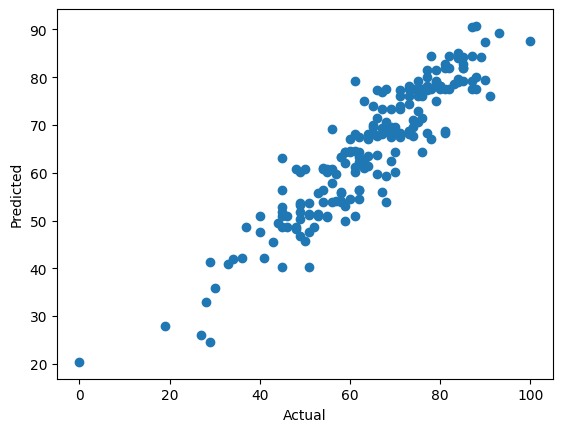

In [63]:
plt.scatter(y_test,y_test_pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")

<Axes: xlabel='math_score'>

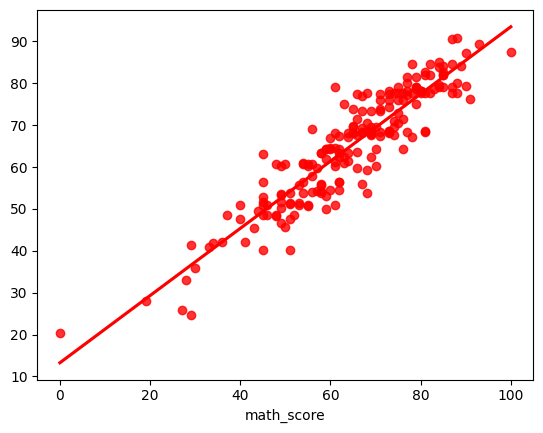

In [64]:
sns.regplot(x=y_test, y=y_test_pred,ci=None,color="r")

In [65]:
pred= pd.DataFrame({"Actual Value":y_test,"Prediccted value":y_test_pred,"Difference":y_test-y_test_pred})
print(pred)

     Actual Value  Prediccted value  Difference
521            91         76.130653   14.869347
737            53         55.748252   -2.748252
740            80         78.166667    1.833333
660            74         77.556391   -3.556391
411            84         83.943182    0.056818
..            ...               ...         ...
408            52         48.605263    3.394737
332            62         54.536946    7.463054
208            74         67.663636    6.336364
613            65         68.173913   -3.173913
78             61         68.120000   -7.120000

[200 rows x 3 columns]
